# 04 — Experiment 2: SSW bubbles (H2)

**What you are looking at.** The Smith–Suchanek–Williams (1988) bubble design
with LLM traders: a 15-period asset market where every certificate pays a
random common dividend from {0, 8, 28, 60} francs each period, so fundamental
value declines linearly 360 → 24. Human subjects famously trade far above
fundamental value and crash near the end. Four pre-registered cells of 30
sessions (HYPOTHESES.md, Amendment A3): a **ZI-C anchor** (budget-constrained
random — the *unstructured*-mispricing benchmark, compared on pattern, never
magnitude), the local 8B model under **paraphrases A and B**, and an
**experienced** cell — the same traders shown a mechanically templated
transcript of their paired paraphrase-A session (fresh dividend path, so the
transcript cannot leak the future). Plus an exploratory **mixed** cell
(3 LLM + 3 ZI-C, 15 sessions).

The pre-registered primary (H2) is a conjunction: **(a)** session RD > 0
(one-sided sign test) **and (b)** a boom–crash shape criterion, both holding
under both paraphrases. Everything below computes from committed logs.


In [1]:
import pandas as pd
from agentic_trading.bubbles import fundamental_values, h2_summary, period_prices, ssw_metrics
from agentic_trading.runner import load_session_logs

CELLS = ("ssw_zi_c", "ssw_llm_a", "ssw_llm_b", "ssw_llm_a_exp")
logs = {c: load_session_logs(f"../results/ssw_h2/sessions/{c}.jsonl.gz") for c in CELLS}
logs["ssw_mixed"] = load_session_logs("../results/ssw_explore/sessions/ssw_mixed.jsonl.gz")
metrics = {c: [ssw_metrics(l) for l in ls] for c, ls in logs.items()}

def col(cell, key):
    xs = [m[key] for m in metrics[cell] if m[key] is not None]
    return sum(xs) / len(xs) if xs else None

rows = []
for cell, ms in metrics.items():
    rows.append({
        "cell": cell,
        "sessions": len(ms),
        "mean RD": round(col(cell, "rd"), 3),
        "mean RAD": round(col(cell, "rad"), 3),
        "amplitude": round(col(cell, "amplitude"), 3) if col(cell, "amplitude") is not None else None,
        "duration": round(col(cell, "duration"), 2) if col(cell, "duration") is not None else None,
        "turnover": round(col(cell, "turnover"), 2),
        "shape-criterion pass": f"{sum(m['shape_ok'] for m in ms)}/{len(ms)}",
        "zero-trade sessions": sum(m["zero_trade_session"] for m in ms),
        "validity": (round(sum(l["meta"]["validity"]["validity_rate"] for l in logs[cell]) / len(ms), 3)
                     if cell != "ssw_zi_c" else None),
    })
pd.set_option("display.width", 160)
pd.DataFrame(rows).set_index("cell")

,sessions,mean RD,mean RAD,amplitude,duration,turnover,shape-criterion pass,zero-trade sessions,validity
cell,,,,,,,,,
ssw_zi_c,30,0.824,0.919,1.332,3.80,9.18,0/30,0,NaN
ssw_llm_a,30,-0.594,0.594,0.828,4.13,3.40,0/30,0,1.000
ssw_llm_b,30,-0.595,0.637,0.058,1.17,0.14,0/30,6,0.992
ssw_llm_a_exp,30,-0.375,0.375,0.400,1.87,0.90,0/30,7,0.997
ssw_mixed,15,0.940,1.047,1.478,3.87,5.86,4/15,0,0.819


## The pre-registered H2 analysis

Per paraphrase: an exact one-sided **sign test** on session RD > 0 (ties
dropped) and an exact one-sided **binomial test** that the boom–crash shape
proportion exceeds 1/2 (peak median-price deviation positive, peaking in
periods 3–12, final two traded periods below half the peak). The H2 p-value
entering the Holm family is the **max of all four** (conjunction rule). The
named secondary: experience reduces RD (one-sided Wilcoxon signed-rank on
matched pairs, inexperienced-A − experienced-A).


In [2]:
summary = h2_summary(
    {"A": logs["ssw_llm_a"], "B": logs["ssw_llm_b"]},
    experienced_logs=logs["ssw_llm_a_exp"],
    paired_inexperienced_logs=logs["ssw_llm_a"],
)
for name, c in summary["paraphrases"].items():
    print(f"paraphrase {name}: RD>0 in {c['n_rd_positive']}/{c['n_rd_nonzero']} "
          f"(sign p={c['p_rd_sign']:.4g}); shape {c['n_shape_ok']}/{c['n_sessions']} "
          f"(binomial p={c['p_shape']:.4g})")
print(f"conjunction p (max of 4) = {summary['conjunction_p']:.4g}; "
      f"H2 supported: {summary['h2_supported']}")
e = summary["experience"]
print(f"experience: mean RD {e['mean_rd_inexperienced']:.3f} -> {e['mean_rd_experienced']:.3f} "
      f"(reduction {e['mean_rd_reduction']:+.3f}, Wilcoxon one-sided p={e['p_wilcoxon']:.4g})")
zic_rd = col("ssw_zi_c", "rd")
print(f"ZI-C anchor mean RD = {zic_rd:.3f} (unstructured mispricing — pattern comparison only)")

paraphrase A: RD>0 in 0/30 (sign p=1); shape 0/30 (binomial p=1)
paraphrase B: RD>0 in 1/17 (sign p=1); shape 0/30 (binomial p=1)
conjunction p (max of 4) = 1; H2 supported: False
experience: mean RD -0.594 -> -0.375 (reduction -0.219, Wilcoxon one-sided p=0.9981)
ZI-C anchor mean RD = 0.824 (unstructured mispricing — pattern comparison only)


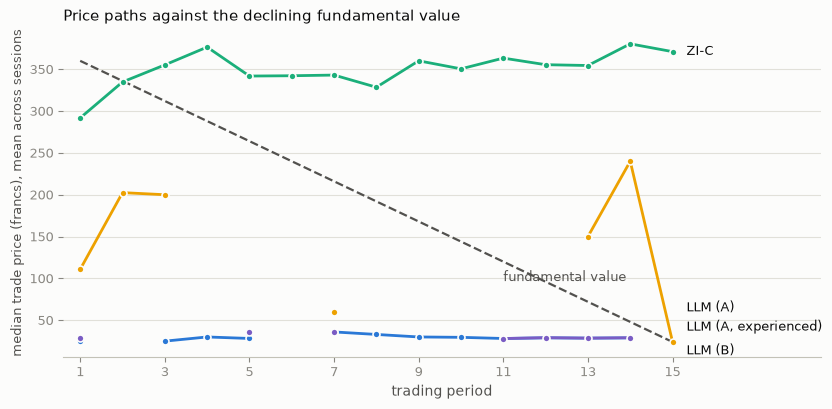

In [3]:
import matplotlib.pyplot as plt
import statistics

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
COLOR = {"ssw_zi_c": "#1baf7a", "ssw_llm_a": "#2a78d6", "ssw_llm_b": "#eda100",
         "ssw_llm_a_exp": "#7a5cc4", "ssw_mixed": "#898781"}
LABEL = {"ssw_zi_c": "ZI-C", "ssw_llm_a": "LLM (A)", "ssw_llm_b": "LLM (B)",
         "ssw_llm_a_exp": "LLM (A, experienced)", "ssw_mixed": "mixed"}

def style_axis(ax):
    ax.set_facecolor(SURFACE)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)

FV = fundamental_values(15, [0, 8, 28, 60])
PERIODS = range(1, 16)

def mean_median_path(cell):
    per_period = {p: [] for p in PERIODS}
    for log in logs[cell]:
        for p, price in period_prices(log, "median").items():
            per_period[p].append(price)
    return [statistics.mean(per_period[p]) if per_period[p] else None for p in PERIODS]

fig, ax = plt.subplots(figsize=(8.6, 4.2))
fig.patch.set_facecolor(SURFACE)
style_axis(ax)
ax.plot(list(PERIODS), FV, color=INK2, linewidth=1.6, linestyle="--")
ax.annotate("fundamental value", (11, FV[10]), xytext=(0, -14), textcoords="offset points",
            color=INK2, fontsize=9)
LABEL_OFFSET = {"ssw_zi_c": 0, "ssw_llm_a": 22, "ssw_llm_a_exp": 8, "ssw_llm_b": -6}
for cell in ("ssw_zi_c", "ssw_llm_a", "ssw_llm_b", "ssw_llm_a_exp"):
    ys = mean_median_path(cell)
    ax.plot(list(PERIODS), ys, color=COLOR[cell], linewidth=2, marker="o", markersize=5,
            markeredgecolor=SURFACE, markeredgewidth=1.2)
    last = max(p for p, y in zip(PERIODS, ys) if y is not None)
    ax.annotate(LABEL[cell], (15, ys[last - 1]), xytext=(10, LABEL_OFFSET[cell]),
                textcoords="offset points", color=INK, fontsize=9, va="center")
ax.set_xlim(0.6, 18.5)
ax.set_xticks([1, 3, 5, 7, 9, 11, 13, 15])
ax.set_xlabel("trading period", color=INK2, fontsize=10)
ax.set_ylabel("median trade price (francs), mean across sessions", color=INK2, fontsize=9)
ax.set_title("Price paths against the declining fundamental value",
             loc="left", color=INK, fontsize=11)
plt.tight_layout(); plt.show()

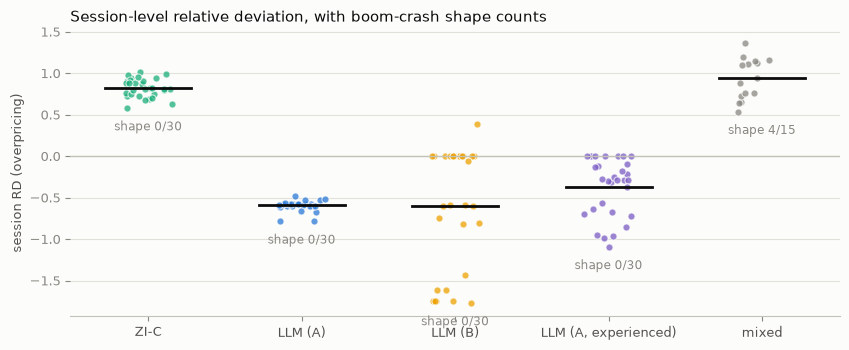

In [4]:
import random as _r

fig, ax = plt.subplots(figsize=(8.6, 3.6))
fig.patch.set_facecolor(SURFACE)
style_axis(ax)
order = ("ssw_zi_c", "ssw_llm_a", "ssw_llm_b", "ssw_llm_a_exp", "ssw_mixed")
rng = _r.Random(7)
for x, cell in enumerate(order):
    rds = [m["rd"] for m in metrics[cell]]
    xs = [x + rng.uniform(-0.16, 0.16) for _ in rds]
    ax.scatter(xs, rds, s=26, color=COLOR[cell], alpha=0.75, edgecolors=SURFACE, linewidths=0.8)
    mean_rd = sum(rds) / len(rds)
    ax.plot([x - 0.28, x + 0.28], [mean_rd, mean_rd], color=INK, linewidth=2)
    shape = sum(m["shape_ok"] for m in metrics[cell])
    ax.annotate(f"shape {shape}/{len(rds)}", (x, min(rds)), xytext=(0, -16),
                textcoords="offset points", color=MUTED, fontsize=8.5, ha="center")
ax.axhline(0, color=BASELINE, linewidth=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([LABEL[c] for c in order], color=INK2, fontsize=9.5)
ax.set_ylabel("session RD (overpricing)", color=INK2, fontsize=9)
ax.set_title("Session-level relative deviation, with boom-crash shape counts",
             loc="left", color=INK, fontsize=11)
plt.tight_layout(); plt.show()

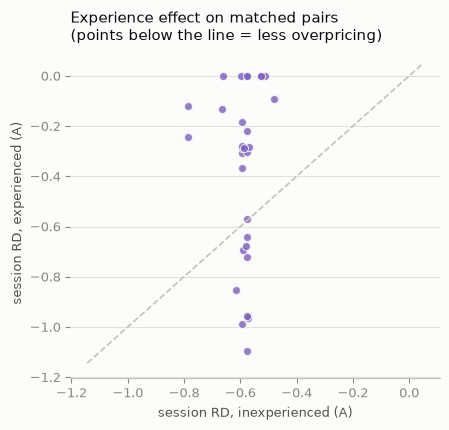

In [5]:
rd_in = [m["rd"] for m in metrics["ssw_llm_a"]]
rd_ex = [m["rd"] for m in metrics["ssw_llm_a_exp"]]
lo = min(rd_in + rd_ex) - 0.05
hi = max(rd_in + rd_ex) + 0.05
fig, ax = plt.subplots(figsize=(4.6, 4.4))
fig.patch.set_facecolor(SURFACE)
style_axis(ax)
ax.plot([lo, hi], [lo, hi], color=BASELINE, linewidth=1.2, linestyle="--")
ax.scatter(rd_in, rd_ex, s=34, color=COLOR["ssw_llm_a_exp"], alpha=0.8,
           edgecolors=SURFACE, linewidths=0.8)
ax.set_xlabel("session RD, inexperienced (A)", color=INK2, fontsize=9.5)
ax.set_ylabel("session RD, experienced (A)", color=INK2, fontsize=9.5)
ax.set_title("Experience effect on matched pairs\n(points below the line = less overpricing)",
             loc="left", color=INK, fontsize=10.5)
plt.tight_layout(); plt.show()

## Human-lab anchors and comparability

Published human SSW-style baselines are **directional anchors, never
equivalence claims**. Inexperienced human markets: positive RD with a
boom–crash pattern in most sessions; RAD typically ≈ 0.2–0.6 (Stöckl, Huber
& Kirchler 2010); amplitude ≈ 1.2 and turnover ≈ 4–6 with experience
reducing all of them (Smith–Suchanek–Williams 1988; Porter & Smith 1995;
the 4.19 average turnover across prior studies is tabulated in Noussair,
Robin & Ruffieux 2001).

| Design deviation (ours vs human labs) | Ours |
| --- | --- |
| Traders | 6 (homogeneous same-model self-play) vs 9–12 humans |
| Incentives | none (sampled tokens) vs cash-paid subjects |
| Activation | 60 seeded uniform polls/period (A4) vs continuous clock time |
| Instructions | paraphrased, relabeled ("certificates", "francs"), never named |
| ZI-C turnover | far above human magnitude at any poll count (A4) — pattern comparisons only |


In [6]:
a = summary["paraphrases"]["A"]
b = summary["paraphrases"]["B"]
conj = summary["conjunction_p"]
exp_p = summary["experience"]["p_wilcoxon"]

from agentic_trading.reproduce import verify_claims
print(verify_claims("04_ssw_bubbles", {
    "H2-1": f"{a['mean_rd']:.2f}",
    "H2-2": f"{b['mean_rd']:.2f}",
    "H2-3": f"{zic_rd:.2f}",
    "H2-4": "<0.001" if conj < 0.001 else f"{conj:.3f}",
    "H2-5": "yes" if summary["h2_supported"] else "no",
    "H2-6": "<0.001" if exp_p < 0.001 else f"{exp_p:.3f}",
    "H2-7": f"{a['n_shape_ok']}/30 / {b['n_shape_ok']}/30",
    "H2-8": f"{summary['experience']['mean_rd_experienced']:.2f}",
}))

OK: 8 claim(s) verified against CLAIMS.md
